In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import seaborn as sns

from niceplots import plot_surface_vars, plot_level_vars, plot_selection, get_color

In [2]:
plt.style.use("~/nice.mplstyle")

In [3]:
fig_dir = "paper-figures/06km"
if not os.path.isdir(fig_dir):
    os.makedirs(fig_dir)

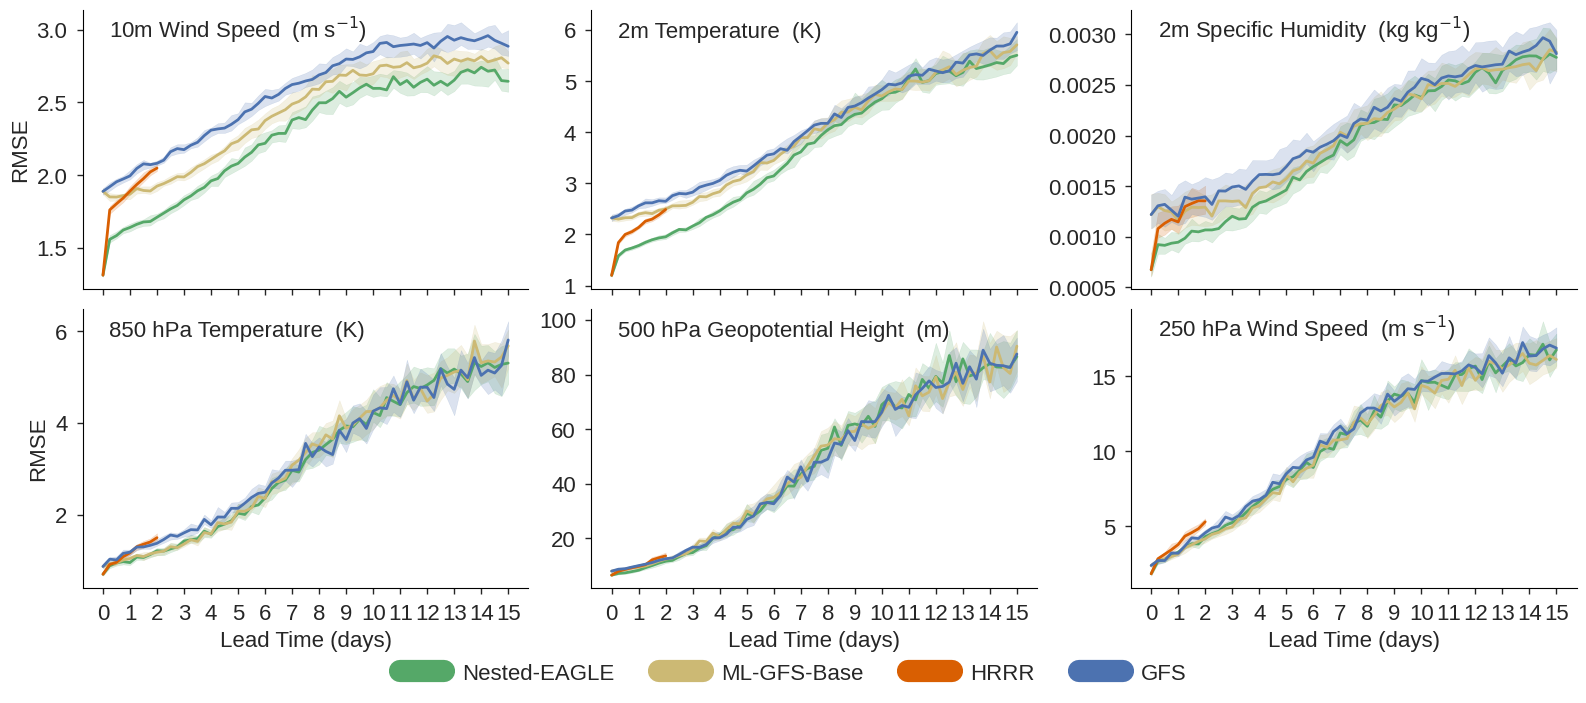

In [4]:
metric = "rmse"
valortest = "testing"
figdict = {}
figdict["Nested-EAGLE"] = xr.load_dataset(f"/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/production/gfs-hrrr/stage1c/inference-{valortest}/obs-metrics/{metric}.convobs.nested-lam.nc", decode_timedelta=True)
figdict["ML-GFS-Base"] = xr.load_dataset(f"/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/production/gfs-only/stage1c/inference-{valortest}/obs-metrics-hrrr/{metric}.convobs.global.nc", decode_timedelta=True)
figdict["HRRR"] = xr.load_dataset(f"/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/baselines/hrrr-forecasts-vs-hrrr-analysis/trim25/obs-metrics-{valortest}/{metric}.convobs.lam.nc", decode_timedelta=True)
figdict["GFS"] = xr.load_dataset(f"/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/baselines/gfs-forecasts-vs-hrrr-analysis/trim25/obs-metrics-{valortest}/{metric}.convobs.lam.nc", decode_timedelta=True)

fig, axs = plot_selection(
    figdict,
    metric_name=metric.upper(),
    variables=["10m_wind_speed", "2m_temperature", "2m_specific_humidity", {"temperature": 850}, {"geopotential_height": 500}, {"wind_speed": 250}],
    nrows=2,
)
fig.savefig(f"{fig_dir}/lam_{metric}.jpeg", dpi=300, bbox_inches="tight")
fig.savefig(f"{fig_dir}/lam_{metric}.pdf", bbox_inches="tight")

/tmp/ipykernel_553880/1507792181.py:43: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=0, rect=[0, 0.1, 1, 1])


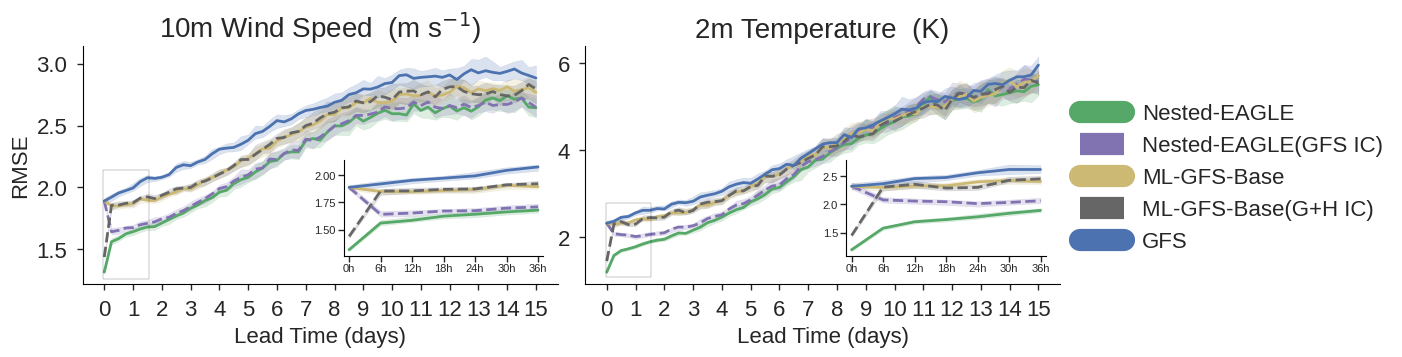

In [5]:
metric = "rmse"
valortest = "testing"
figdict = {}
figdict["Nested-EAGLE"] = xr.load_dataset(f"/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/production/gfs-hrrr/stage1c/inference-{valortest}/obs-metrics/{metric}.convobs.nested-lam.nc", decode_timedelta=True)
figdict["Nested-EAGLE(GFS IC)"] = xr.load_dataset(f"/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/production/gfs-hrrr/stage1c/inference-{valortest}-fakehrrr/obs-metrics/{metric}.convobs.nested-lam.nc", decode_timedelta=True)
figdict["ML-GFS-Base"] = xr.load_dataset(f"/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/production/gfs-only/stage1c/inference-{valortest}/obs-metrics-hrrr/{metric}.convobs.global.nc", decode_timedelta=True)
figdict["ML-GFS-Base(G+H IC)"] = xr.load_dataset(f"/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/production/gfs-only/stage1c/inference-{valortest}-fakegfs/obs-metrics-hrrr/{metric}.convobs.global.nc", decode_timedelta=True)
figdict["GFS"] = xr.load_dataset(f"/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/baselines/gfs-forecasts-vs-hrrr-analysis/trim25/obs-metrics-{valortest}/{metric}.convobs.lam.nc", decode_timedelta=True)

fig, axs = plot_surface_vars(figdict, metric_name=metric.upper(), surface_vars=("10m_wind_speed", "2m_temperature"), one_legend=False)
inset_pad = 1
inset_max_fhr = 36
for ax, varname in zip(axs.flatten(), ("10m_wind_speed", "2m_temperature")):
    axins = ax.inset_axes([0.55, 0.12, 0.42, 0.40])
    for label, xds in figdict.items():
        color, linestyle = get_color(label)
        plotme = xds[varname].sel(fhr=xds.fhr <= inset_max_fhr)
        df = plotme.to_dataframe().reset_index()
        sns.lineplot(data=df, x="fhr", y=varname, ax=axins, color=color, linestyle=linestyle, estimator="median")
    inset_ticks = [f for f in xds.fhr.values if 0 <= f <= inset_max_fhr]
    axins.set_xlim(-inset_pad, inset_max_fhr + inset_pad)
    axins.set_xticks(inset_ticks, labels=[f"{int(f)}h" for f in inset_ticks])
    axins.set(xlabel="", title="", ylabel="")
    axins.tick_params(labelsize=8, pad=2)
    indicator = ax.indicate_inset_zoom(axins, edgecolor="black")
    indicator.connectors[0].set_visible(False)
    indicator.connectors[1].set_visible(False)
    indicator.connectors[2].set_visible(False)
    indicator.connectors[3].set_visible(False)

handles, labels = axs.flatten()[0].get_legend_handles_labels()
legend = fig.legend(
    handles,
    labels,
    loc='center left',
    bbox_to_anchor=(1.0, 0.55),
    ncols=1,
    frameon=False,
)
for line in legend.get_lines():
    line.set_linewidth(16)
if len(axs.shape) == 1:
    plt.tight_layout(pad=0, rect=[0, 0.1, 1, 1])
[ax.legend().remove() for ax in axs.flatten()];

fig.savefig(f"{fig_dir}/swapped_ic_{metric}.jpeg", dpi=300, bbox_inches="tight")
fig.savefig(f"{fig_dir}/swapped_ic_{metric}.pdf", bbox_inches="tight")

The difference between ML-GFS-Base(G+H IC) and Nested-EAGLE and fhr = 0 is the regridding. The ML GFS base version has taken HRRR initial conditions,
regridded them to 1/4 degree, and then back to 6km. This is a lossy process.